In [1]:
!pip install -q streamlit pyngrok

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import os

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.1 MB/s eta 0:00:00:00:0100:01


2026-04-20 06:21:29.620633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776666089.815089      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776666089.869945      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776666090.301449      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776666090.301489      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776666090.301492      55 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)

print("Train:", x_train.shape, "Test:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [3]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(64, (5,5), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(128, (7,7), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='cifar10_cnn')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776666122.612540      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776666122.618979      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,504,586 (5.74 MB)

 Trainable params: 1,504,138 (5.74 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=3, verbose=1),
]

history = model.fit(
    x_train, y_train_oh,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


I0000 00:00:1776666127.744483     134 service.cc:152] XLA service 0x78056800a150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776666127.744521     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776666127.744527     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776666128.269111     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


 19/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1683 - loss: 3.1816

I0000 00:00:1776666132.408255     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3218 - loss: 1.9568 - val_accuracy: 0.4715 - val_loss: 1.5044 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5221 - loss: 1.3266 - val_accuracy: 0.5862 - val_loss: 1.2813 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6335 - loss: 1.0453 - val_accuracy: 0.5686 - val_loss: 1.4618 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7056 - loss: 0.8547 - val_accuracy: 0.6707 - val_loss: 0.9526 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7535 - loss: 0.7137 - val_accuracy: 0.7031 - val_loss: 0.8860 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7905 - loss: 0.6054 - val_accuracy: 0.7249 - val_loss: 0.8219 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8265 - loss: 0.4972 - val_accur

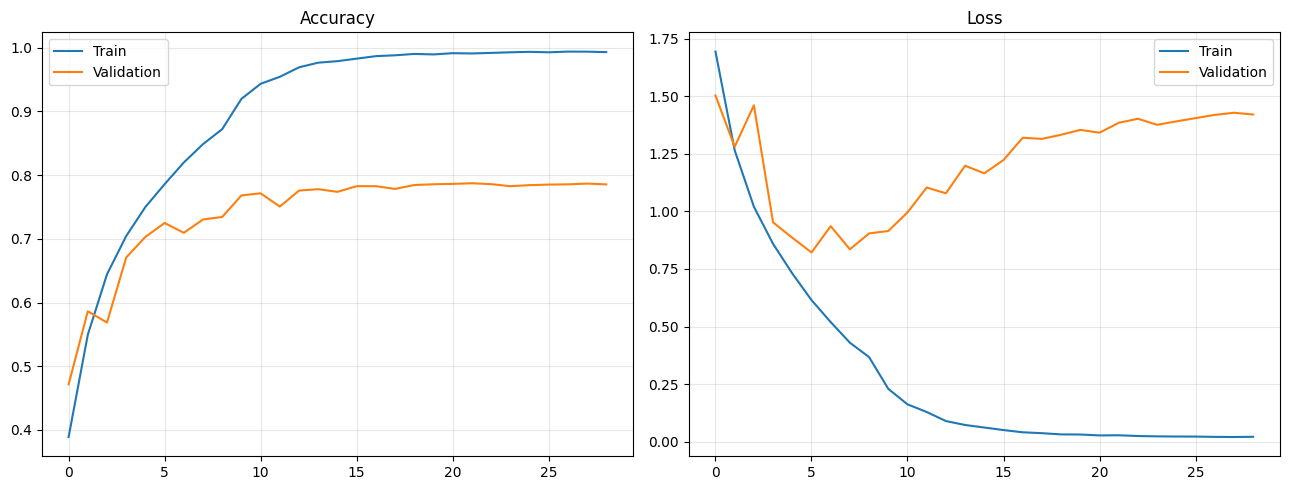

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
loss_fn = tf.keras.losses.CategoricalCrossentropy()

def get_gradient(model, images, labels):
    with tf.GradientTape() as tape:
        tape.watch(images)
        loss = loss_fn(labels, model(images, training=False))
    return tape.gradient(loss, images)

def fgsm_attack(model, images, labels, epsilon=0.03):
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    labels = tf.convert_to_tensor(labels, dtype=tf.float32)
    adv = images + epsilon * tf.sign(get_gradient(model, images, labels))
    return tf.clip_by_value(adv, 0, 1).numpy()

def bim_attack(model, images, labels, epsilon=0.03, alpha=0.005, iters=10):
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    labels = tf.convert_to_tensor(labels, dtype=tf.float32)
    adv = images
    for _ in range(iters):
        adv = tf.convert_to_tensor(adv)
        adv = adv + alpha * tf.sign(get_gradient(model, adv, labels))
        adv = tf.clip_by_value(adv, images - epsilon, images + epsilon)
        adv = tf.clip_by_value(adv, 0, 1).numpy()
    return adv

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.005, iters=20):
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    labels = tf.convert_to_tensor(labels, dtype=tf.float32)
    adv = images + tf.random.uniform(tf.shape(images), -epsilon, epsilon)
    adv = tf.clip_by_value(adv, 0, 1)
    for _ in range(iters):
        adv = tf.convert_to_tensor(adv)
        adv = adv + alpha * tf.sign(get_gradient(model, adv, labels))
        adv = tf.clip_by_value(adv, images - epsilon, images + epsilon)
        adv = tf.clip_by_value(adv, 0, 1).numpy()
    return adv

In [7]:
x_s, y_s = x_test[:500], y_test_oh[:500]
results   = []

def get_acc(model, x, y):
    loss, acc = model.evaluate(x, y, verbose=0)
    return acc

# Clean
results.append(("Clean", "-", get_acc(model, x_s, y_s)))

# FGSM
for eps in [0.01, 0.03, 0.05, 0.1]:
    adv = fgsm_attack(model, x_s, y_s, epsilon=eps)
    results.append((f"FGSM", eps, get_acc(model, adv, y_s)))

# BIM
adv_bim = bim_attack(model, x_s, y_s)
results.append(("BIM", 0.03, get_acc(model, adv_bim, y_s)))

# PGD
adv_pgd = pgd_attack(model, x_s, y_s)
results.append(("PGD", 0.03, get_acc(model, adv_pgd, y_s)))

print(f"\n{'Attack':<10} {'Epsilon':>10} {'Accuracy':>10}")
print("="*35)
for name, eps, acc in results:
    print(f"{name:<10} {str(eps):>10} {acc*100:>9.2f}%")


Attack        Epsilon   Accuracy
Clean               -     79.40%
FGSM             0.01     32.00%
FGSM             0.03     23.40%
FGSM             0.05     20.60%
FGSM              0.1     18.40%
BIM              0.03      9.40%
PGD              0.03      5.80%


In [12]:
os.makedirs('/kaggle/working/model', exist_ok=True)
model.save('/kaggle/working/model/cifar10_cnn.keras')
print(" Model saved!")

 Model saved!


In [9]:
from IPython.display import FileLink
import shutil

shutil.make_archive('/kaggle/working/cifar10_model', 'zip', '/kaggle/working/model')
FileLink('/kaggle/working/cifar10_model.zip')

/kaggle/working/cifar10_model.zip

In [10]:
!ls /kaggle/working

cifar10_model.zip  model
